<a href="https://colab.research.google.com/github/ADHEERA12/Thiranx-DataScience-1/blob/main/SecondProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
De

/tmp/ipykernel_3491/1334621703.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_3491/1334621703.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

Random Forest Accuracy: 0.8268156424581006


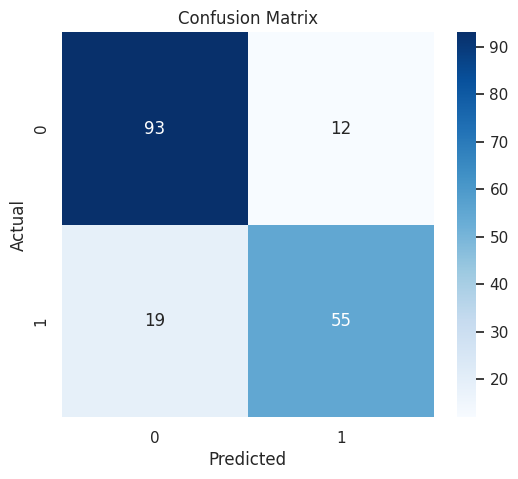

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       105
           1       0.82      0.74      0.78        74

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179

       Feature  Importance
2          Sex    0.257117
0  PassengerId    0.194417
6         Fare    0.193276
3          Age    0.165378
1       Pclass    0.079907
4        SibSp    0.041973
5        Parch    0.035313
7     Embarked    0.032619


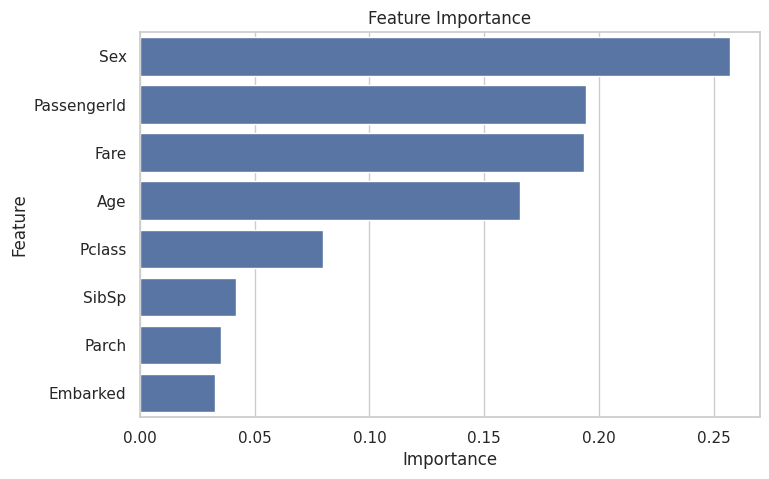

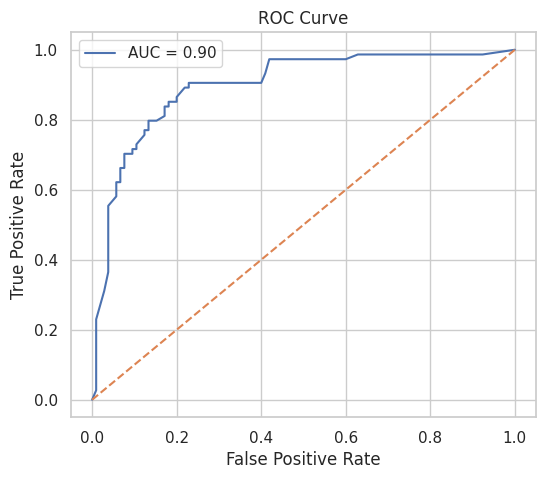

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Load dataset
df = pd.read_csv("/content/train.csv")

print(df.head())

# Fill missing values
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Drop unnecessary columns
df.drop(columns=["Name", "Ticket", "Cabin"], inplace=True)

# Convert categorical columns
encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])

# Features and target
target = "Survived"

X = df.drop(columns=[target])
y = df[target]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Classification Report
print(classification_report(y_test, rf_pred))

# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

# ROC Curve
y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr,
         label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()